# EDA of BKNG minute-level dataset

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Loading data and basic dataset operations

In [3]:
df = pd.read_csv('data/BKNG_engineering.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Basic dataset information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes.value_counts())

Dataset Shape: (378649, 56)

Column Names:
['Open', 'High', 'Low', 'Close', 'Volume', 'Transactions', '52w_high', '52w_low', 'Volume_30D_avg', 'MA_100D_proxy', 'Price_30D_zscore', 'Close/52w_high', 'Close/52w_low', 'MA_50', 'MA_200', 'Close/MA_50', 'Close/MA_200', 'intraday_amplitude', 'overnight_gap', 'VWAP', 'Close/VWAP', 'Volume/30D_avg', 'Volume_intraday_zscore', 'volume_acceleration', 'high_volume_bar_60min_95p', 'consec_high_volume_bars_5', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'ROC_5', 'ROC_15', 'ATR_14', 'realized_vol_5min', 'realized_vol_30min', 'BB_MA_20', 'BB_std_20', 'BB_upper', 'BB_lower', 'BB_width', 'MA_50_slope', 'MA_200_slope', 'tenkan_sen', 'kijun_sen', 'senkou_span_a', 'senkou_span_b', 'chikou_span', 'days_since_ATH', 'hours_since_open', 'day_of_week', 'month_of_year', 'covid_period', 'high_vol_regime_90q', 'bull_market_proxy', 'bear_market_proxy', 'event']

Data Types:
float64    45
int64       5
bool        5
object      1
Name: count, dtype: int64


In [4]:
# Check for missing values
missing_analysis = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Percentage', ascending=False)

print("Missing Values Analysis:")
print(missing_analysis[missing_analysis['Missing_Count'] > 0])

Missing Values Analysis:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []


In [ ]:
# I cut the dataset off at 31/12/2024 because too much data is missing after that date
cutoff_date = '2024-12-31'
df = df[df.index <= cutoff_date]
df.tail()

In [6]:
# leave only records that were created in normal trading hours
df = df.between_time('09:30', '16:00')
df.tail()

,Open,High,Low,Close,Volume,Transactions,52w_high,52w_low,Volume_30D_avg,MA_100D_proxy,...,chikou_span,days_since_ATH,hours_since_open,day_of_week,month_of_year,covid_period,high_vol_regime_90q,bull_market_proxy,bear_market_proxy,event
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-30 15:50:00,4960.8200,4960.8200,4960.8200,4960.8200,179,25,5300.34,3305.62,198266.7,4450.618,...,5007.48,18,6.333333,0,12,False,False,True,False,normal
2024-12-30 15:52:00,4958.1000,4958.1000,4958.1000,4958.1000,108,8,5300.34,3305.62,198266.7,4450.618,...,5002.56,18,6.366667,0,12,False,False,True,False,normal
2024-12-30 15:56:00,4972.3342,4972.3342,4972.3342,4972.3342,332,43,5300.34,3305.62,198266.7,4450.618,...,5009.04,18,6.433333,0,12,False,False,True,False,normal
2024-12-30 15:58:00,4972.2900,4980.8850,4972.2900,4980.8850,1800,83,5300.34,3305.62,198266.7,4450.618,...,5010.16,18,6.466667,0,12,False,False,True,False,normal
2024-12-30 15:59:00,4977.8750,4977.8750,4977.8750,4977.8750,309,14,5300.34,3305.62,198266.7,4450.618,...,4999.99,18,6.483333,0,12,False,False,True,False,normal


In [7]:
print("First Date:", df.index.min())
print("Last Date:", df.index.max())

First Date: 2018-02-27 14:30:00
Last Date: 2024-12-30 15:59:00


## Year-by-year closing price charts

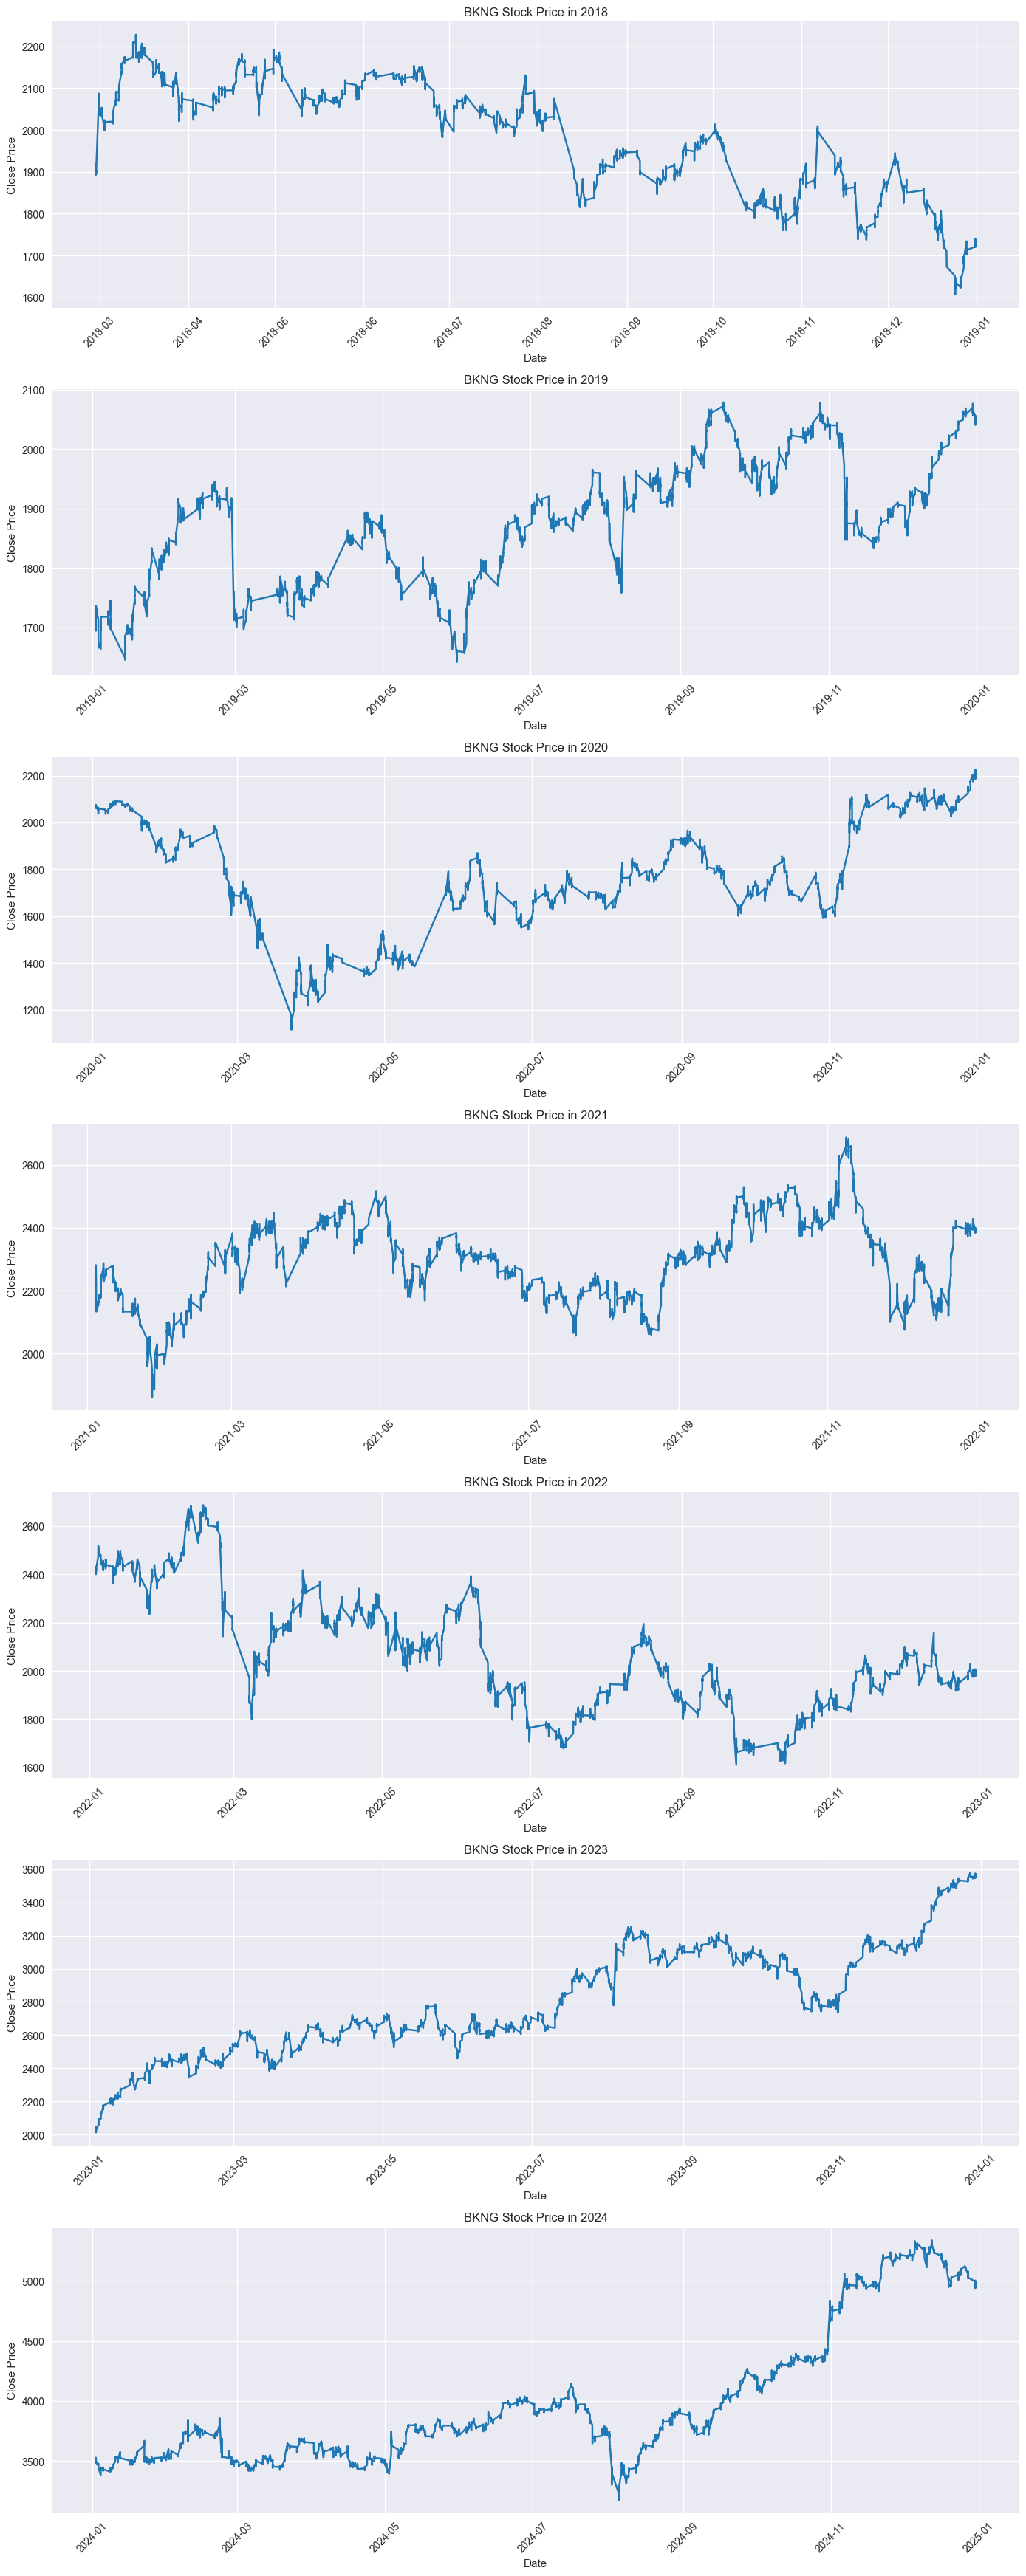

In [8]:
# Get list of unique years
years = sorted(df.index.year.unique())

# Create subplots: one row per year
fig, axes = plt.subplots(len(years), 1, figsize=(14, 5 * len(years)), sharex=False)

# If only one year, axes won't be iterable
if len(years) == 1:
    axes = [axes]

# Loop and plot each year on its own axis
for ax, year in zip(axes, years):
    year_data = df[df.index.year == year]
    ax.plot(year_data.index, year_data['Close'], label=f'{year}', color='tab:blue')
    ax.set_title(f'BKNG Stock Price in {year}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Detecting timeline gaps - daily level

In [9]:
df_daily = df["Close"].resample('B').last()
timeline_gaps_sum = df_daily.isnull().sum()
print("Number of missing business days:", timeline_gaps_sum)
business_days = pd.date_range(start=df_daily.index.min(), end=df_daily.index.max(), freq='B')
print("Number of Business Days in Dataset:", len(business_days))
print("Percentage of missing days:", round(timeline_gaps_sum/len(business_days), 2) * 100, "%")

Number of missing business days: 215
Number of Business Days in Dataset: 1785
Percentage of missing days: 12.0 %


## Target counts

In [ ]:
# Event distribution analysis
event_counts = df['event'].value_counts()
event_percentages = (event_counts / len(df)) * 100

print("Event Distribution:")
for event, count in event_counts.items():
    print(f"{event}: {count:,} ({event_percentages[event]:.3f}%)")

# Visualize event distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
event_counts.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Event Distribution (Counts)')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart (excluding 'normal' for better visibility of rare events)
rare_events = event_counts[event_counts.index != 'normal']
ax2.pie(rare_events.values, labels=rare_events.index, autopct='%1.2f%%')
ax2.set_title('Rare Events Distribution (Excluding Normal)')

plt.tight_layout()
plt.show()

## Price action visualization (Last 10k minutes)

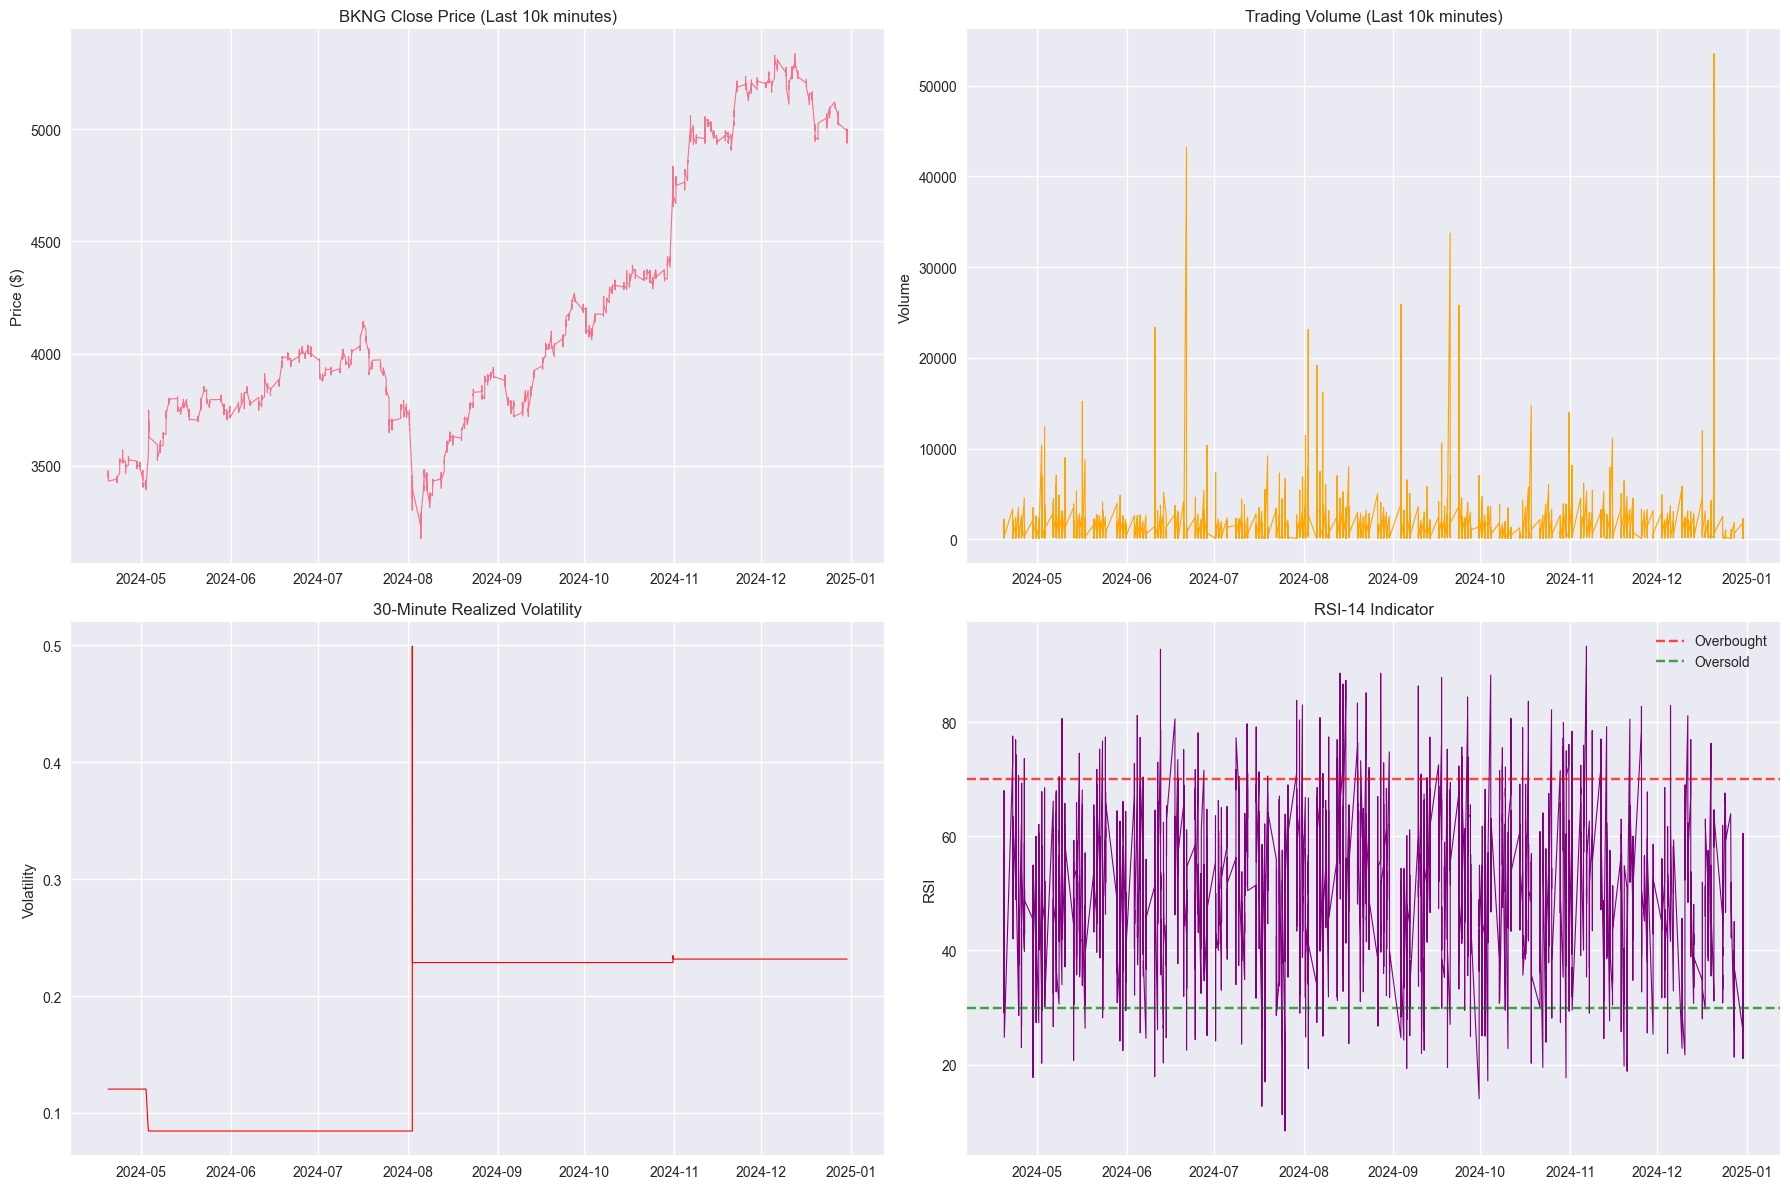

In [11]:
# Basic price action visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Price evolution
axes[0,0].plot(df.index[-10000:], df['Close'][-10000:], linewidth=0.8)
axes[0,0].set_title('BKNG Close Price (Last 10k minutes)')
axes[0,0].set_ylabel('Price ($)')

# Volume over time
axes[0,1].plot(df.index[-10000:], df['Volume'][-10000:], color='orange', linewidth=0.8)
axes[0,1].set_title('Trading Volume (Last 10k minutes)')
axes[0,1].set_ylabel('Volume')

# Intraday volatility
axes[1,0].plot(df.index[-10000:], df['realized_vol_30min'][-10000:], color='red', linewidth=0.8)
axes[1,0].set_title('30-Minute Realized Volatility')
axes[1,0].set_ylabel('Volatility')

# RSI indicator
axes[1,1].plot(df.index[-10000:], df['RSI_14'][-10000:], color='purple', linewidth=0.8)
axes[1,1].axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Overbought')
axes[1,1].axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Oversold')
axes[1,1].set_title('RSI-14 Indicator')
axes[1,1].set_ylabel('RSI')
axes[1,1].legend()

plt.tight_layout()
plt.show()


I plotted the last 10k minutes so the charts are readable. What I looked at:

- Close price to see recent movement.
- Volume next to price to see when trading was active.
- 30 minute realized volatility to find the calm and the noisy periods.
- RSI-14 with the 70 and 30 lines, so I can see overbought and oversold spots.

## Key financial metrics summary

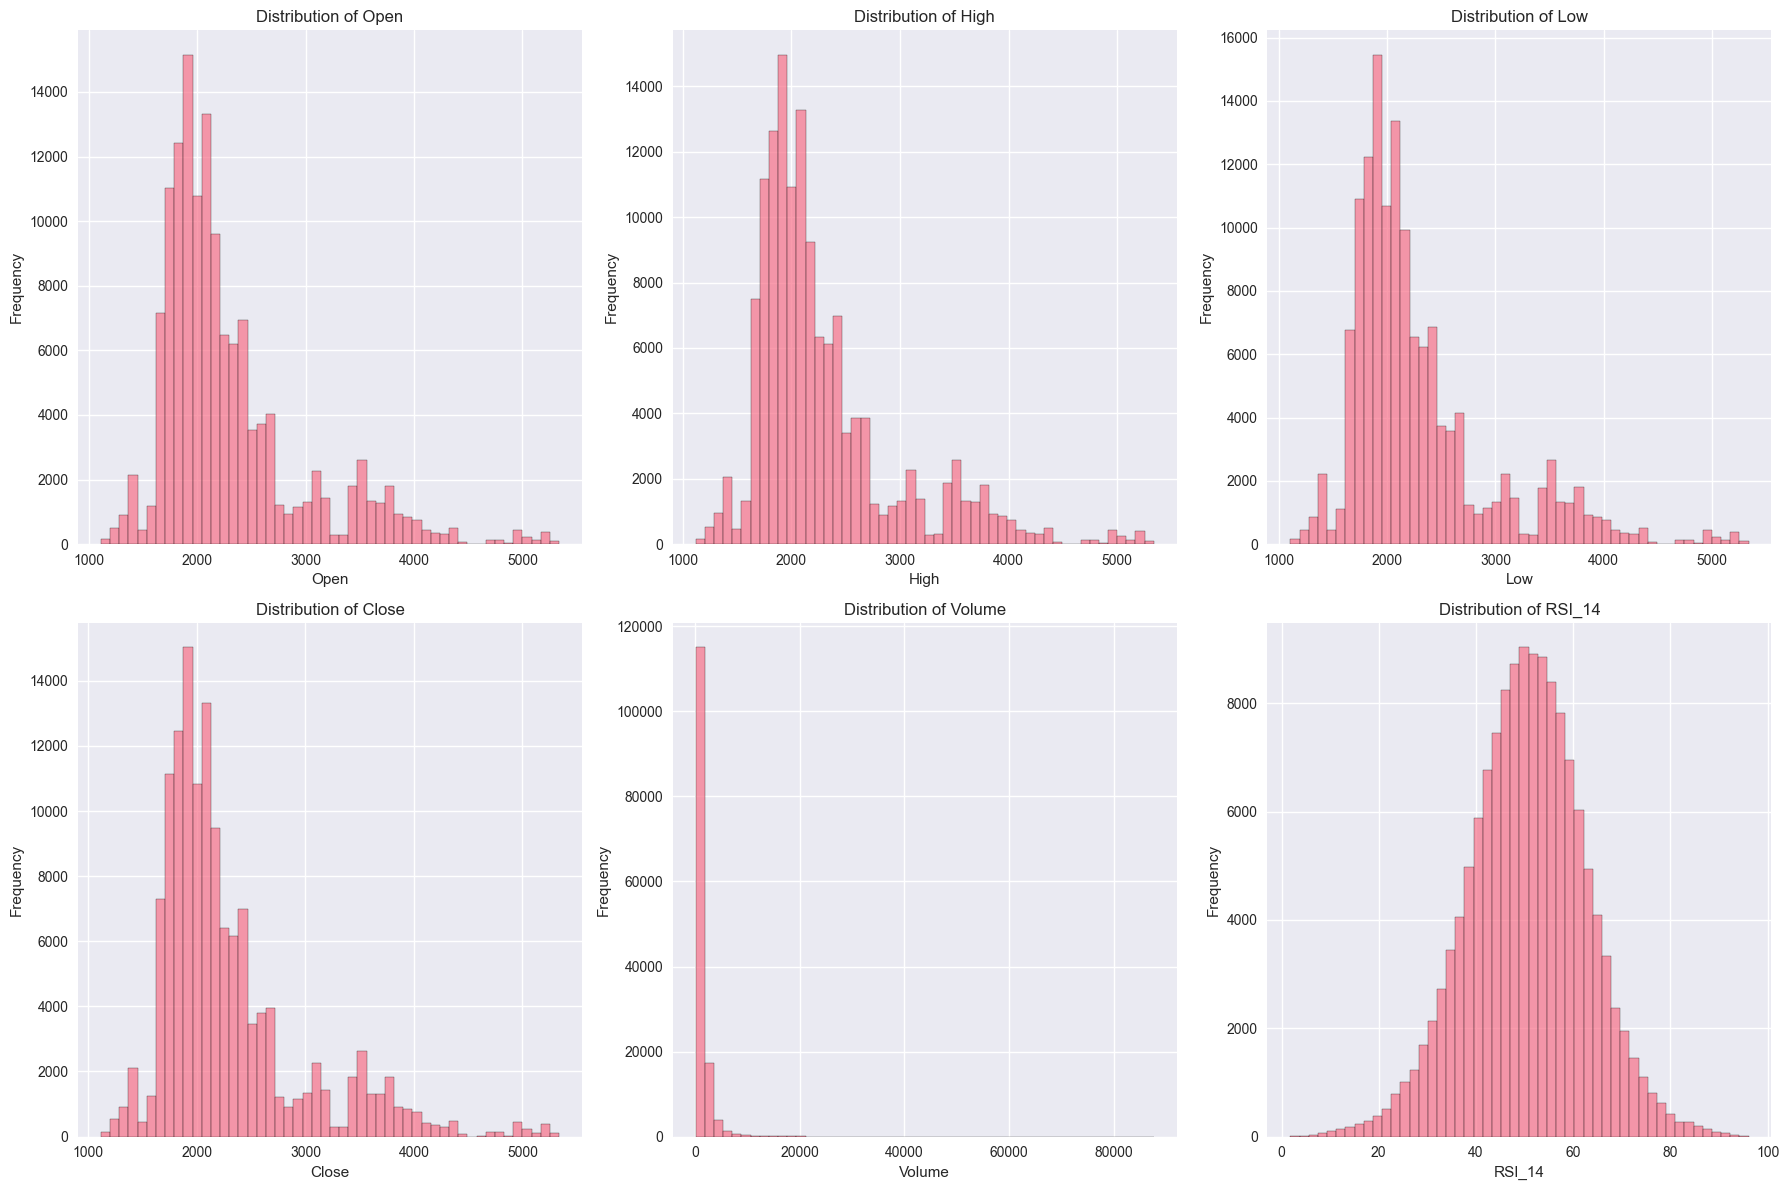

In [12]:
# Key financial metrics summary
key_features = ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI_14', 'MACD',
                'ATR_14', 'realized_vol_30min', 'BB_width']

# Distribution plots for key features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(key_features[:6]):
    axes[i].hist(df[feature].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


I made distribution plots for Open, High, Low, Close, Volume and RSI. I did this to see which features are skewed and how spread out they are, before we decide what to feed the model.

## Correlation Heatmap

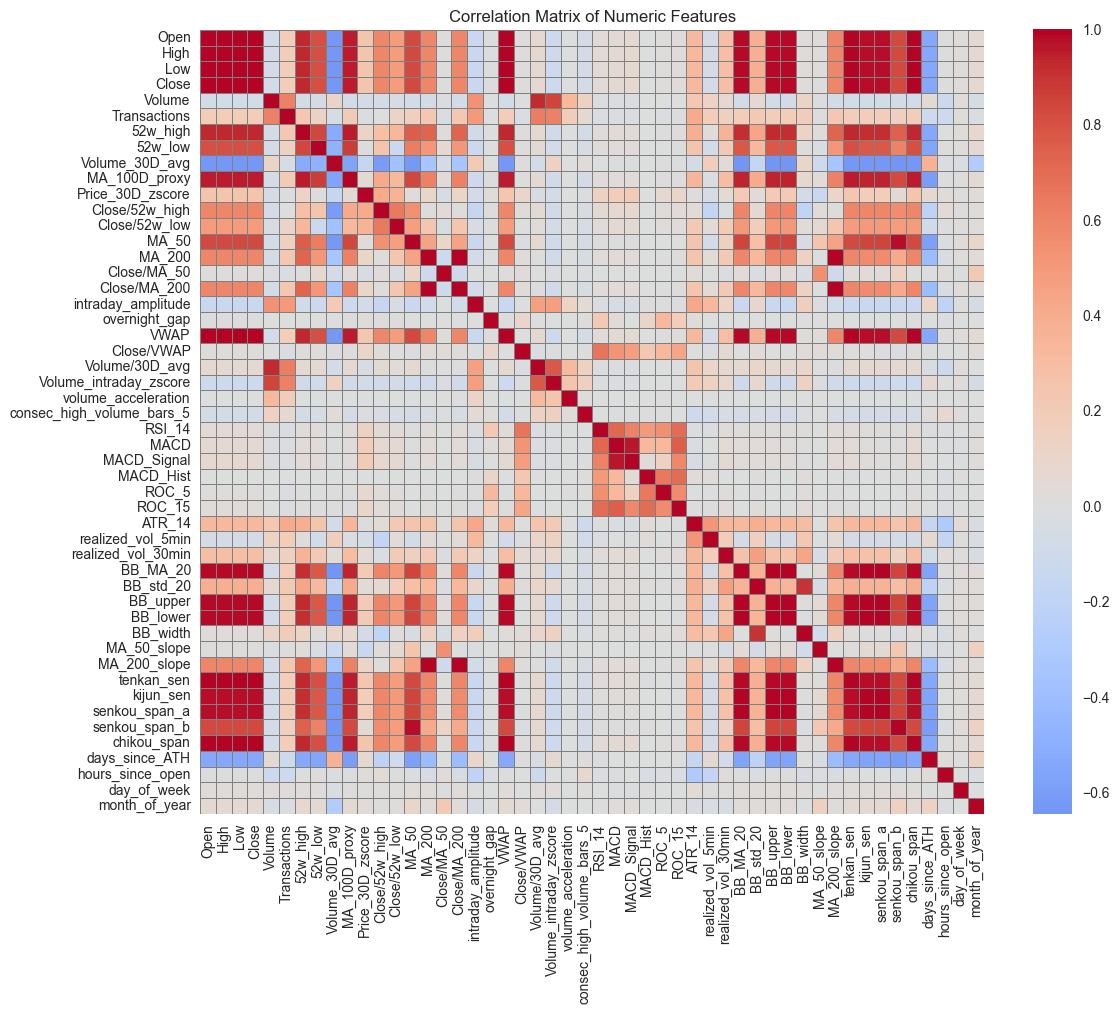

In [13]:
numeric_features = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=False, cmap='coolwarm', center=0,
            square=True,
            linewidths=0.5, linecolor='gray')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

I computed the correlation matrix for the numeric features and plotted it as a heatmap. I wanted to see which price and indicator columns move together, so we can drop ones that are basically the same and avoid multicollinearity in the model.

## Hourly patterns

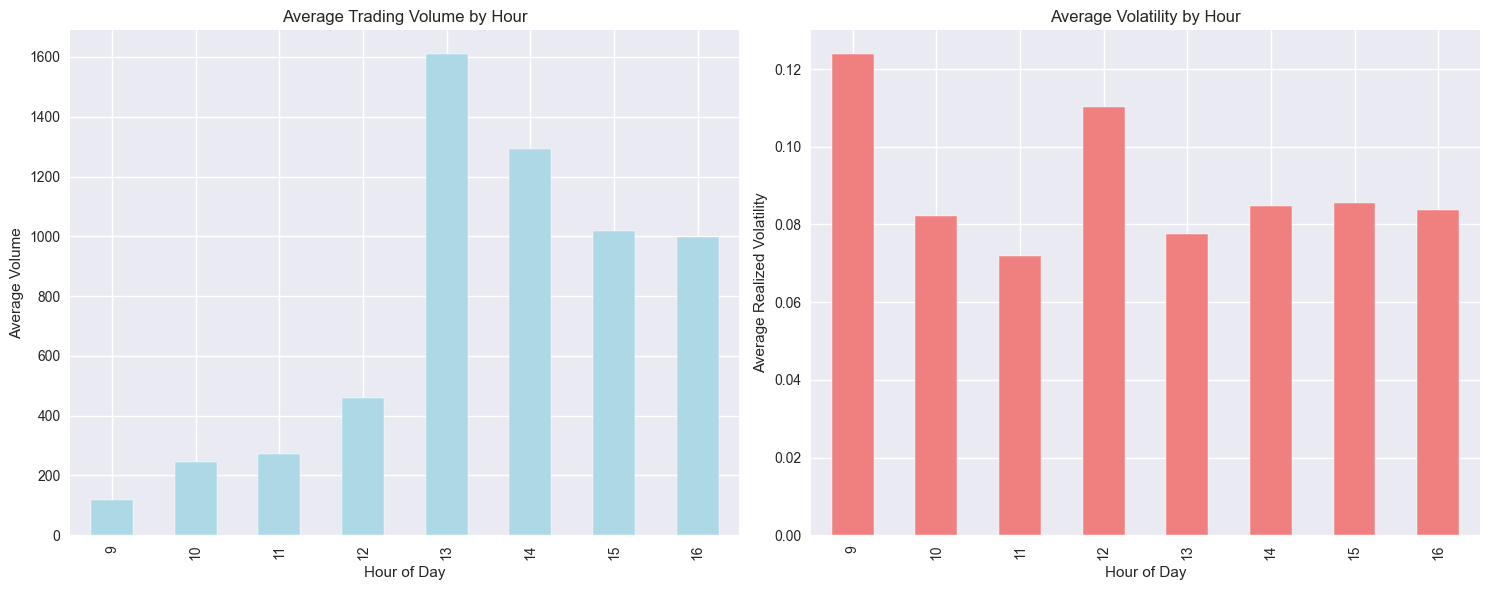

In [14]:
# Extract hour from datetime index for intraday analysis
df['Hour'] = df.index.hour
df['Minute'] = df.index.minute

# Average volume by hour
hourly_volume = df.groupby('Hour')['Volume'].mean()
hourly_volatility = df.groupby('Hour')['realized_vol_30min'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Volume pattern
hourly_volume.plot(kind='bar', ax=ax1, color='lightblue')
ax1.set_title('Average Trading Volume by Hour')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Volume')

# Volatility pattern
hourly_volatility.plot(kind='bar', ax=ax2, color='lightcoral')
ax2.set_title('Average Volatility by Hour')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Average Realized Volatility')

plt.tight_layout()
plt.show()


## Important features by event type box plots

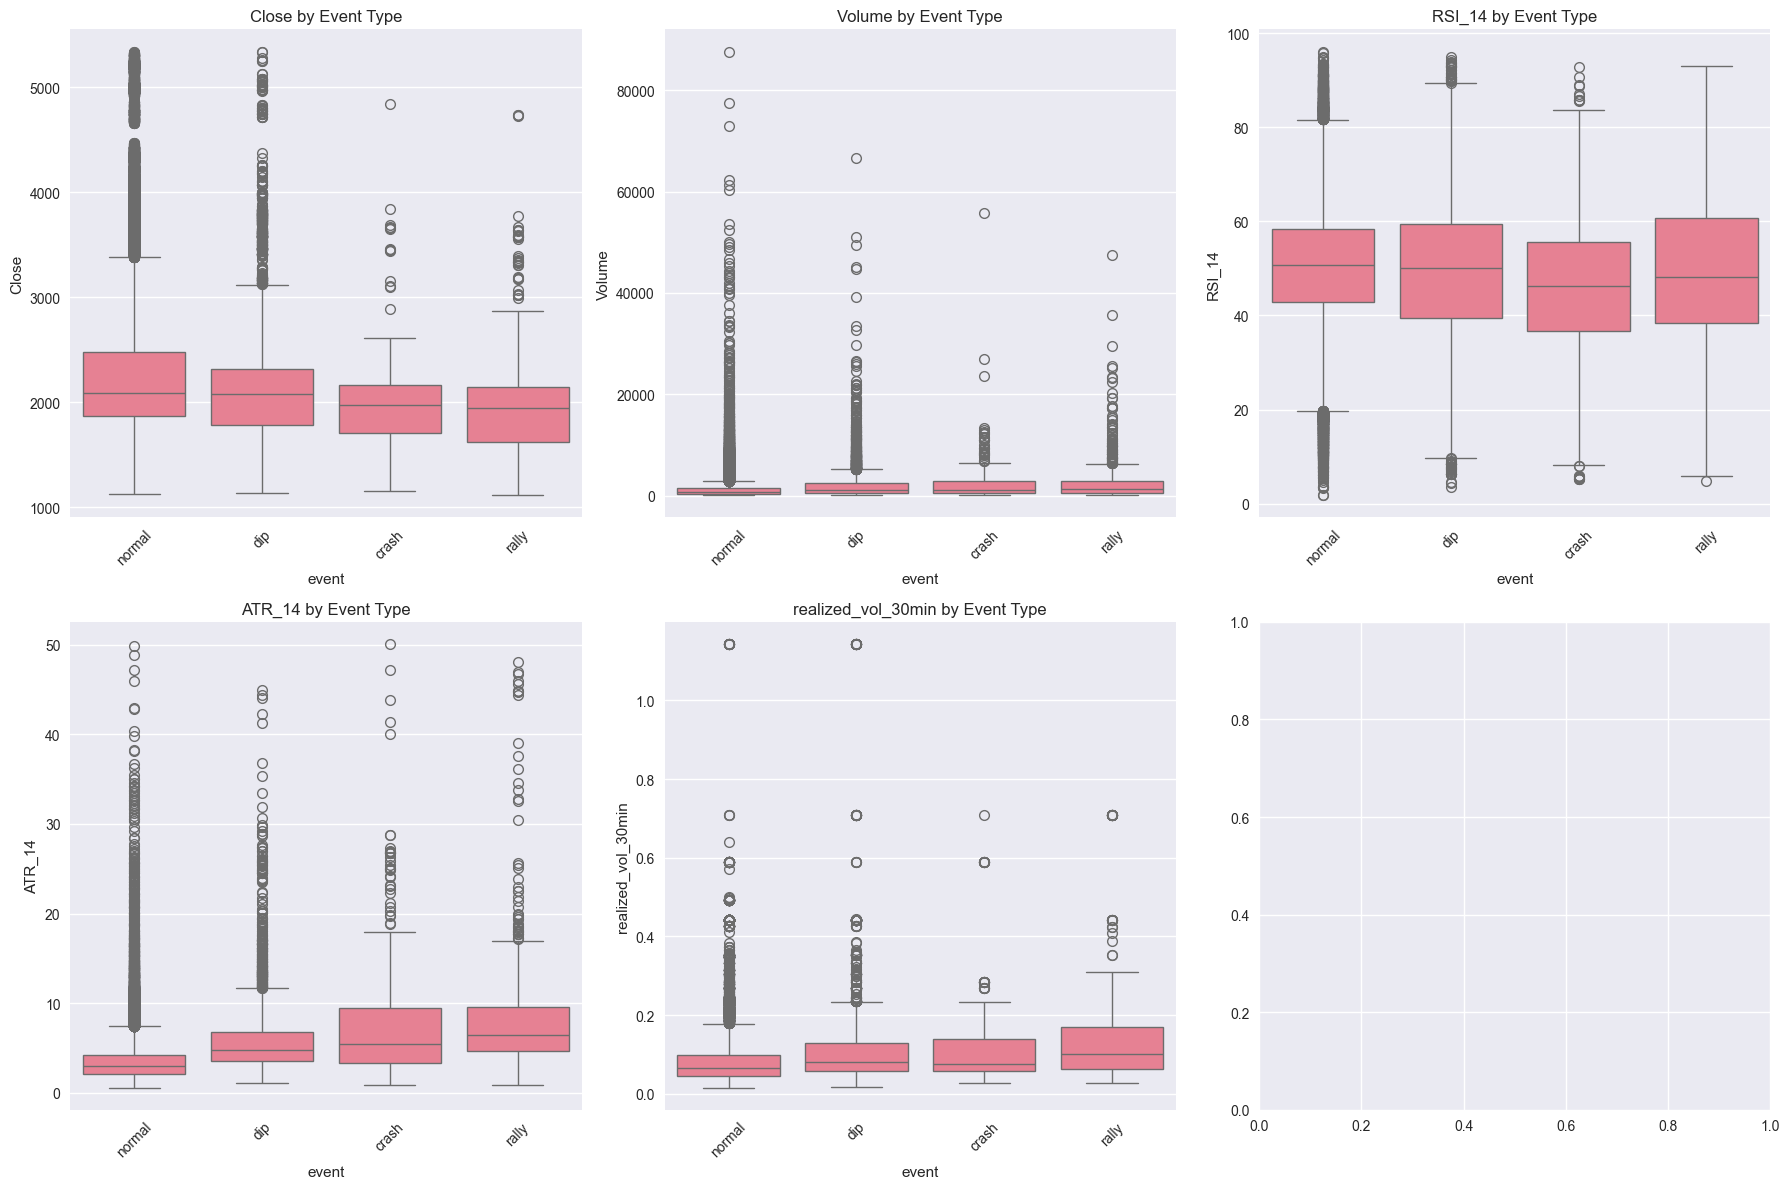


Feature Means by Event Type:
              Close       Volume     RSI_14    ATR_14  realized_vol_30min
event                                                                    
crash   1940.033185  2405.371728  44.941746  7.897203            0.113999
dip     2161.750574  2054.611263  49.408140  5.767940            0.112324
normal  2303.463265  1179.117766  50.612391  3.410966            0.082155
rally   1919.357500  2548.016112  49.240424  7.945455            0.134655


In [15]:
# Analyze features for different event types
event_features = ['Close', 'Volume', 'RSI_14', 'ATR_14', 'realized_vol_30min']

# Box plots for each feature by event type
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(event_features):
    if i < len(axes):
        sns.boxplot(data=df, x='event', y=feature, ax=axes[i])
        axes[i].set_title(f'{feature} by Event Type')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistical comparison by event type
print("\nFeature Means by Event Type:")
event_comparison = df.groupby('event')[event_features].mean()
print(event_comparison)


## Volume vs. Price Change analysis

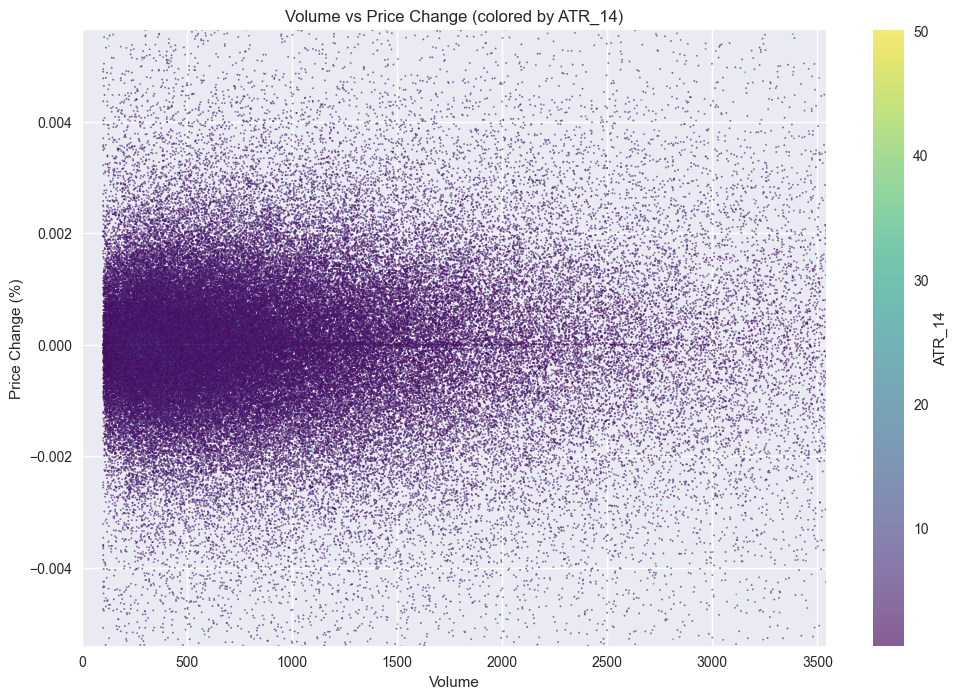

In [16]:
# Volume vs Price Change analysis
df['Price_Change'] = df['Close'].pct_change()
df['Volume_MA'] = df['Volume'].rolling(window=20).mean()

# Scatter plot: Volume vs Price Change
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Volume'], df['Price_Change'],
                     c=df['ATR_14'], cmap='viridis', alpha=0.6, s=1)
plt.colorbar(scatter, label='ATR_14')
plt.xlabel('Volume')
plt.ylabel('Price Change (%)')
plt.title('Volume vs Price Change (colored by ATR_14)')
plt.xlim(0, df['Volume'].quantile(0.95))
plt.ylim(df['Price_Change'].quantile(0.01), df['Price_Change'].quantile(0.99))
plt.show()


## Temporal event distribution analysis

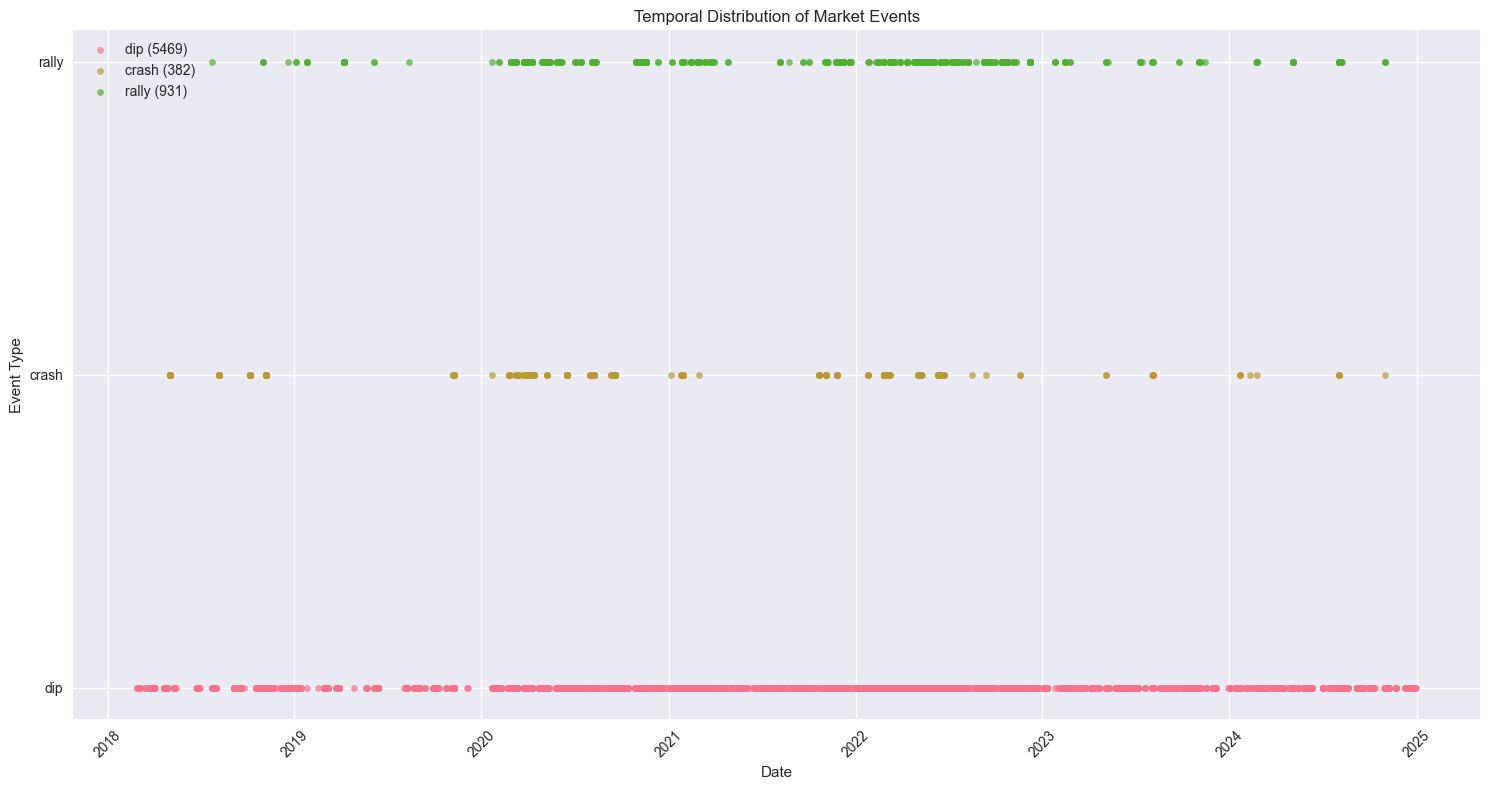

In [17]:
# Analyze temporal distribution of events
df_events = df[df['event'] != 'normal'].copy()

plt.figure(figsize=(15, 8))
for event_type in df_events['event'].unique():
    event_data = df_events[df_events['event'] == event_type]
    plt.scatter(event_data.index, [event_type] * len(event_data),
               alpha=0.7, s=20, label=f'{event_type} ({len(event_data)})')

plt.title('Temporal Distribution of Market Events')
plt.xlabel('Date')
plt.ylabel('Event Type')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Mutual Information Score

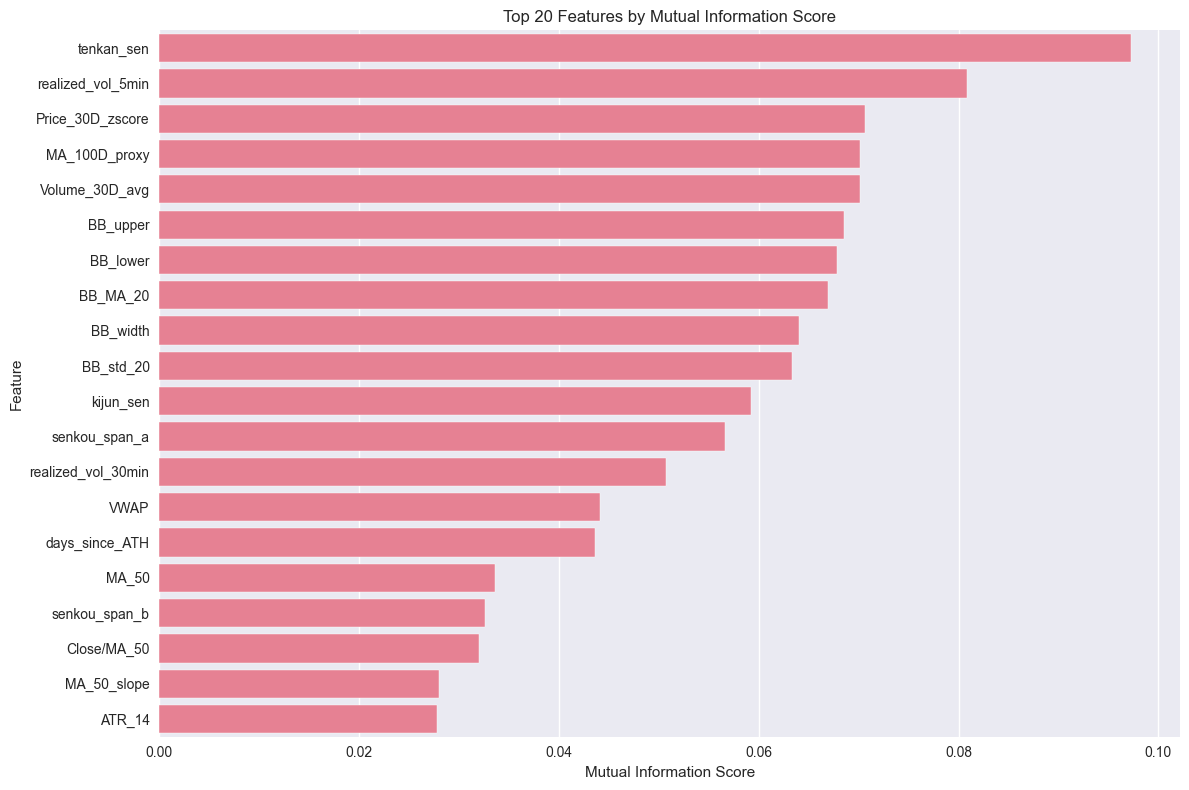

Top 10 Most Important Features:
              Feature  MI_Score
42         tenkan_sen  0.097303
33  realized_vol_5min  0.080836
10   Price_30D_zscore  0.070669
9       MA_100D_proxy  0.070146
8      Volume_30D_avg  0.070138
37           BB_upper  0.068560
38           BB_lower  0.067793
35           BB_MA_20  0.066975
39           BB_width  0.064037
36          BB_std_20  0.063311


In [18]:
# Quick feature importance using mutual information
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Prepare data for mutual information
le = LabelEncoder()
y_encoded = le.fit_transform(df['event'])

# Select relevant features (exclude date-related and target)
feature_cols = [col for col in df.columns if col not in ['event', 'Hour', 'Minute']]
X = df[feature_cols].fillna(0)  # Simple fill for this analysis

# Calculate mutual information
mi_scores = mutual_info_classif(X, y_encoded, random_state=42)
mi_df = pd.DataFrame({
    'Feature': feature_cols,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_features = mi_df.head(20)
sns.barplot(data=top_features, x='MI_Score', y='Feature')
plt.title('Top 20 Features by Mutual Information Score')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(mi_df.head(10))
